# Семинар 3. Решающие деревья и ансамбли

**План занятия:**

1. Как дерево выбирает предикат: критерии информативности.
2. Переобучение и ограничение глубины.
3. Бэггинг и случайный лес.
4. Градиентный бустинг.
5. Важность признаков.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(42)

## 1. Критерии информативности

Для классификации доля неопределённости в узле измеряется энтропией
$H(p) = -\sum_k p_k \log_2 p_k$ или критерием Джини $G(p) = 1 - \sum_k p_k^2$.
Дерево выбирает предикат, максимизирующий прирост информации.

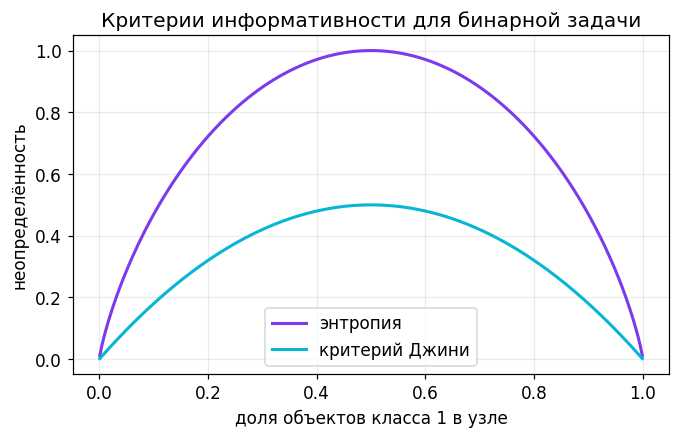

In [2]:
p = np.linspace(0.001, 0.999, 300)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
gini = 2 * p * (1 - p)

plt.plot(p, entropy, label="энтропия", color="#7c3aed", lw=2)
plt.plot(p, gini, label="критерий Джини", color="#06b6d4", lw=2)
plt.xlabel("доля объектов класса 1 в узле"); plt.ylabel("неопределённость")
plt.title("Критерии информативности для бинарной задачи")
plt.legend()
plt.show()

## 2. Переобучение дерева

Дерево без ограничений идеально запоминает обучающую выборку.
Смотрим, как глубина влияет на качество.

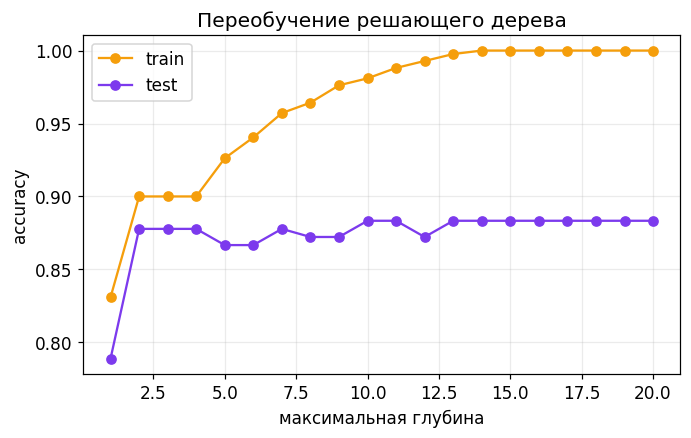

Лучшая глубина по тесту: 10


In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=600, noise=0.32, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

depths = range(1, 21)
train_scores, test_scores = [], []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_tr, y_tr)
    train_scores.append(tree.score(X_tr, y_tr))
    test_scores.append(tree.score(X_te, y_te))

plt.plot(list(depths), train_scores, marker="o", label="train", color="#f59e0b")
plt.plot(list(depths), test_scores, marker="o", label="test", color="#7c3aed")
plt.xlabel("максимальная глубина"); plt.ylabel("accuracy")
plt.title("Переобучение решающего дерева")
plt.legend()
plt.show()

print("Лучшая глубина по тесту:", list(depths)[int(np.argmax(test_scores))])

## 3. Разделяющие поверхности

Одно дерево даёт «ступенчатую» границу, ансамбль — гладкую и устойчивую.

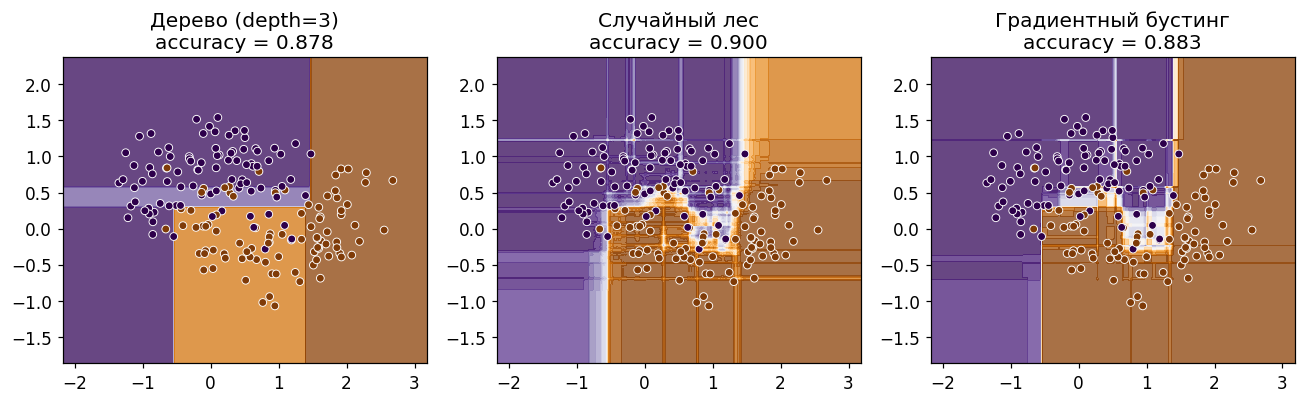

In [4]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Дерево (depth=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Случайный лес": RandomForestClassifier(n_estimators=300, random_state=42),
    "Градиентный бустинг": GradientBoostingClassifier(random_state=42),
}

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 300),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 300))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr, y_tr)
    zz = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap="PuOr_r", alpha=0.75)
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap="PuOr_r", edgecolor="white", s=26, linewidth=0.6)
    ax.set_title(f"{name}\naccuracy = {model.score(X_te, y_te):.3f}")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 4. Важность признаков

На реальных данных полезно понимать, какие признаки модель считает значимыми.

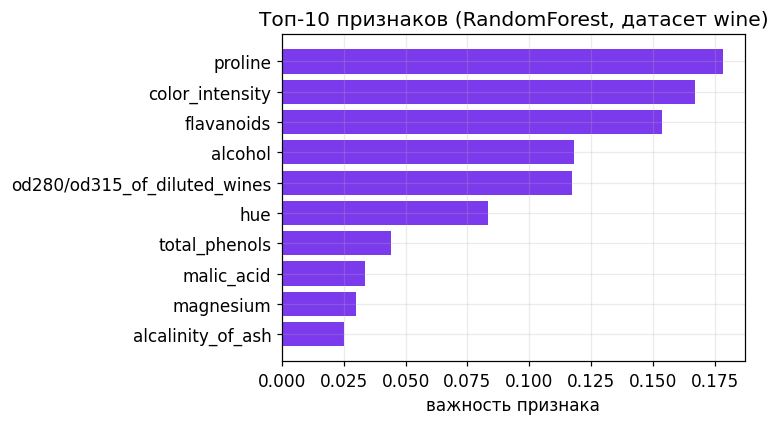

In [5]:
from sklearn.datasets import load_wine

wine = load_wine()
forest = RandomForestClassifier(n_estimators=400, random_state=0).fit(wine.data, wine.target)

order = np.argsort(forest.feature_importances_)[-10:]

plt.barh(np.array(wine.feature_names)[order], forest.feature_importances_[order], color="#7c3aed")
plt.xlabel("важность признака")
plt.title("Топ-10 признаков (RandomForest, датасет wine)")
plt.tight_layout()
plt.show()

## Задание для самостоятельной работы

1. Сравните `RandomForestClassifier` и `GradientBoostingClassifier` по времени обучения
   и качеству при `n_estimators` от 10 до 500.
2. Постройте зависимость качества случайного леса от `max_features`.
   Почему случайность в выборе признаков улучшает ансамбль?
3. Реализуйте бэггинг над решающими деревьями «руками» (без `BaggingClassifier`)
   и убедитесь, что качество близко к `RandomForest`.